In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
DATA_PATH = r"D:\projects\AI-Stock-Analytics-System\data\processed"

df = pd.read_csv(
    os.path.join(DATA_PATH, "cleaned_stock_data.csv")
)

In [3]:
df.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2005-01-03,238.508957,239.486735,236.588314,238.508957,1031091.0,ACC
1,2005-01-04,245.318558,246.785235,238.299487,239.556627,2377765.0,ACC
2,2005-01-05,243.432800,250.661408,234.912141,245.143927,3886135.0,ACC
3,2005-01-06,239.975601,248.915312,237.461301,243.048626,2954242.0,ACC
4,2005-01-07,244.794708,247.797887,240.255006,247.797887,1817394.0,ACC


In [4]:
df.shape


(481533, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481533 entries, 0 to 481532
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Date    481533 non-null  object 
 1   Close   481533 non-null  float64
 2   High    481533 non-null  float64
 3   Low     481533 non-null  float64
 4   Open    481533 non-null  float64
 5   Volume  481533 non-null  float64
 6   Ticker  481533 non-null  object 
dtypes: float64(5), object(2)
memory usage: 25.7+ MB


In [6]:
df["Date"] = pd.to_datetime(df["Date"])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481533 entries, 0 to 481532
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   Date    481533 non-null  datetime64[ns]
 1   Close   481533 non-null  float64       
 2   High    481533 non-null  float64       
 3   Low     481533 non-null  float64       
 4   Open    481533 non-null  float64       
 5   Volume  481533 non-null  float64       
 6   Ticker  481533 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 25.7+ MB


In [8]:
df = df.sort_values(
    by=["Ticker", "Date"]
).reset_index(drop=True)

In [9]:
df.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2005-01-03,238.508957,239.486735,236.588314,238.508957,1031091.0,ACC
1,2005-01-04,245.318558,246.785235,238.299487,239.556627,2377765.0,ACC
2,2005-01-05,243.432800,250.661408,234.912141,245.143927,3886135.0,ACC
3,2005-01-06,239.975601,248.915312,237.461301,243.048626,2954242.0,ACC
4,2005-01-07,244.794708,247.797887,240.255006,247.797887,1817394.0,ACC


In [10]:
df.groupby("Ticker")

In [11]:
df["Daily_Return"] = (
    df.groupby("Ticker")["Close"]
      .pct_change()
)

In [12]:
df[["Ticker", "Date", "Close", "Daily_Return"]].head(15)

,Ticker,Date,Close,Daily_Return
0,ACC,2005-01-03,238.508957,NaN
1,ACC,2005-01-04,245.318558,0.028551
2,ACC,2005-01-05,243.432800,-0.007687
3,ACC,2005-01-06,239.975601,-0.014202
4,ACC,2005-01-07,244.794708,0.020082
5,ACC,2005-01-10,240.953522,-0.015691
6,ACC,2005-01-11,233.305832,-0.031739
7,ACC,2005-01-12,232.712173,-0.002545
8,ACC,2005-01-13,245.039215,0.052971
9,ACC,2005-01-14,240.778870,-0.017386


In [13]:
df[["Ticker", "Date", "Close", "Daily_Return"]].tail(15)

,Ticker,Date,Close,Daily_Return
481518,ZYDUSLIFE,2026-07-07,1151.964844,0.004443
481519,ZYDUSLIFE,2026-07-08,1146.969238,-0.004337
481520,ZYDUSLIFE,2026-07-09,1157.959473,0.009582
481521,ZYDUSLIFE,2026-07-10,1149.766846,-0.007075
481522,ZYDUSLIFE,2026-07-13,1130.284302,-0.016945
481523,ZYDUSLIFE,2026-07-14,1132.582153,0.002033
481524,ZYDUSLIFE,2026-07-15,1155.861328,0.020554
481525,ZYDUSLIFE,2026-07-16,1152.864014,-0.002593
481526,ZYDUSLIFE,2026-07-17,1142.673096,-0.008840
481527,ZYDUSLIFE,2026-07-20,1147.968384,0.004634


In [14]:
df["MA5"] = (
    df.groupby("Ticker")["Close"]
      .transform(lambda x: x.rolling(window=5).mean())
)

In [15]:
df[["Ticker", "Date", "Close", "MA5"]].head(10)

,Ticker,Date,Close,MA5
0,ACC,2005-01-03,238.508957,NaN
1,ACC,2005-01-04,245.318558,NaN
2,ACC,2005-01-05,243.432800,NaN
3,ACC,2005-01-06,239.975601,NaN
4,ACC,2005-01-07,244.794708,242.406125
5,ACC,2005-01-10,240.953522,242.895038
6,ACC,2005-01-11,233.305832,240.492493
7,ACC,2005-01-12,232.712173,238.348367
8,ACC,2005-01-13,245.039215,239.361090
9,ACC,2005-01-14,240.778870,238.557922


In [16]:
df["MA10"] = (
    df.groupby("Ticker")["Close"]
      .transform(lambda x: x.rolling(window=10).mean())
)

In [17]:
df["MA20"] = (
    df.groupby("Ticker")["Close"]
      .transform(lambda x: x.rolling(window=20).mean())
)

In [18]:
df["MA50"] = (
    df.groupby("Ticker")["Close"]
      .transform(lambda x: x.rolling(window=50).mean())
)

In [19]:
df[["Ticker","Date","Close","MA5","MA10","MA20","MA50"]].head(60)

,Ticker,Date,Close,MA5,MA10,MA20,MA50
0,ACC,2005-01-03,238.508957,NaN,NaN,NaN,NaN
1,ACC,2005-01-04,245.318558,NaN,NaN,NaN,NaN
2,ACC,2005-01-05,243.432800,NaN,NaN,NaN,NaN
3,ACC,2005-01-06,239.975601,NaN,NaN,NaN,NaN
4,ACC,2005-01-07,244.794708,242.406125,NaN,NaN,NaN
5,ACC,2005-01-10,240.953522,242.895038,NaN,NaN,NaN
6,ACC,2005-01-11,233.305832,240.492493,NaN,NaN,NaN
7,ACC,2005-01-12,232.712173,238.348367,NaN,NaN,NaN
8,ACC,2005-01-13,245.039215,239.361090,NaN,NaN,NaN
9,ACC,2005-01-14,240.778870,238.557922,240.482024,NaN,NaN


In [20]:
df["EMA20"] = (df.groupby("Ticker")["Close"].transform(lambda x: x.ewm(span=20,
adjust=False).mean()))

In [21]:
df[["Ticker","Date","Close","MA20","EMA20"]].head(30)

,Ticker,Date,Close,MA20,EMA20
0,ACC,2005-01-03,238.508957,NaN,238.508957
1,ACC,2005-01-04,245.318558,NaN,239.157490
2,ACC,2005-01-05,243.432800,NaN,239.564663
3,ACC,2005-01-06,239.975601,NaN,239.603800
4,ACC,2005-01-07,244.794708,NaN,240.098172
5,ACC,2005-01-10,240.953522,NaN,240.179634
6,ACC,2005-01-11,233.305832,NaN,239.524986
7,ACC,2005-01-12,232.712173,NaN,238.876147
8,ACC,2005-01-13,245.039215,NaN,239.463106
9,ACC,2005-01-14,240.778870,NaN,239.588416


In [22]:
# Calculate price change
delta = df.groupby("Ticker")["Close"].diff()
# Positive changes (gains)
gain = delta.where(delta > 0, 0)
# Negative changes (losses)
loss = -delta.where(delta < 0, 0)
# Average gain over 14 days
avg_gain = gain.groupby(df["Ticker"]).transform(
    lambda x: x.rolling(14).mean())
# Average loss over 14 days
avg_loss = loss.groupby(df["Ticker"]).transform(
    lambda x: x.rolling(14).mean())
# Relative Strength
rs = avg_gain / avg_loss
# RSI
df["RSI"] = 100 - (100 / (1 + rs))

In [23]:
df[["Ticker","Date","Close","RSI"]].head(30)

,Ticker,Date,Close,RSI
0,ACC,2005-01-03,238.508957,NaN
1,ACC,2005-01-04,245.318558,NaN
2,ACC,2005-01-05,243.432800,NaN
3,ACC,2005-01-06,239.975601,NaN
4,ACC,2005-01-07,244.794708,NaN
5,ACC,2005-01-10,240.953522,NaN
6,ACC,2005-01-11,233.305832,NaN
7,ACC,2005-01-12,232.712173,NaN
8,ACC,2005-01-13,245.039215,NaN
9,ACC,2005-01-14,240.778870,NaN


In [24]:
df["EMA12"] = (
    df.groupby("Ticker")["Close"]
      .transform(
          lambda x: x.ewm(
              span=12,
              adjust=False
          ).mean()
      )
)

In [25]:
df["EMA26"] = (
    df.groupby("Ticker")["Close"]
      .transform(
          lambda x: x.ewm(
              span=26,
              adjust=False
          ).mean()
      )
)

In [26]:
df["MACD"] = df["EMA12"] - df["EMA26"]

In [27]:
df[
    [
        "Ticker",
        "Date",
        "Close",
        "EMA12",
        "EMA26",
        "MACD"
    ]
].head(30)

,Ticker,Date,Close,EMA12,EMA26,MACD
0,ACC,2005-01-03,238.508957,238.508957,238.508957,0.000000
1,ACC,2005-01-04,245.318558,239.556588,239.013372,0.543216
2,ACC,2005-01-05,243.432800,240.152928,239.340737,0.812191
3,ACC,2005-01-06,239.975601,240.125647,239.387764,0.737883
4,ACC,2005-01-07,244.794708,240.843964,239.788278,1.055686
5,ACC,2005-01-10,240.953522,240.860819,239.874593,0.986227
6,ACC,2005-01-11,233.305832,239.698513,239.388018,0.310496
7,ACC,2005-01-12,232.712173,238.623692,238.893511,-0.269819
8,ACC,2005-01-13,245.039215,239.610695,239.348748,0.261947
9,ACC,2005-01-14,240.778870,239.790415,239.454683,0.335732


In [28]:
df["Signal_Line"] = (
    df.groupby("Ticker")["MACD"]
      .transform(
          lambda x: x.ewm(
              span=9,
              adjust=False
          ).mean()
      )
)

In [29]:
df[
    [
        "Ticker",
        "Date",
        "MACD",
        "Signal_Line"
    ]
].head(30)

,Ticker,Date,MACD,Signal_Line
0,ACC,2005-01-03,0.000000,0.000000
1,ACC,2005-01-04,0.543216,0.108643
2,ACC,2005-01-05,0.812191,0.249353
3,ACC,2005-01-06,0.737883,0.347059
4,ACC,2005-01-07,1.055686,0.488784
5,ACC,2005-01-10,0.986227,0.588273
6,ACC,2005-01-11,0.310496,0.532717
7,ACC,2005-01-12,-0.269819,0.372210
8,ACC,2005-01-13,0.261947,0.350158
9,ACC,2005-01-14,0.335732,0.347272


In [30]:
df["MACD_Histogram"] = df["MACD"] - df["Signal_Line"]

In [31]:
df[
    [
        "Ticker",
        "Date",
        "MACD",
        "Signal_Line",
        "MACD_Histogram"
    ]
].head(30)

,Ticker,Date,MACD,Signal_Line,MACD_Histogram
0,ACC,2005-01-03,0.000000,0.000000,0.000000
1,ACC,2005-01-04,0.543216,0.108643,0.434573
2,ACC,2005-01-05,0.812191,0.249353,0.562838
3,ACC,2005-01-06,0.737883,0.347059,0.390824
4,ACC,2005-01-07,1.055686,0.488784,0.566902
5,ACC,2005-01-10,0.986227,0.588273,0.397954
6,ACC,2005-01-11,0.310496,0.532717,-0.222222
7,ACC,2005-01-12,-0.269819,0.372210,-0.642029
8,ACC,2005-01-13,0.261947,0.350158,-0.088210
9,ACC,2005-01-14,0.335732,0.347272,-0.011541


In [32]:
rolling_std = (
    df.groupby("Ticker")["Close"]
      .transform(
          lambda x: x.rolling(20).std()
      )
)

In [33]:
df["Upper_Band"] = df["MA20"] + (2 * rolling_std)
df["Lower_Band"] = df["MA20"] - (2 * rolling_std)

In [34]:
df[
    [
        "Ticker",
        "Date",
        "Close",
        "MA20",
        "Upper_Band",
        "Lower_Band"
    ]
].head(30)

,Ticker,Date,Close,MA20,Upper_Band,Lower_Band
0,ACC,2005-01-03,238.508957,NaN,NaN,NaN
1,ACC,2005-01-04,245.318558,NaN,NaN,NaN
2,ACC,2005-01-05,243.432800,NaN,NaN,NaN
3,ACC,2005-01-06,239.975601,NaN,NaN,NaN
4,ACC,2005-01-07,244.794708,NaN,NaN,NaN
5,ACC,2005-01-10,240.953522,NaN,NaN,NaN
6,ACC,2005-01-11,233.305832,NaN,NaN,NaN
7,ACC,2005-01-12,232.712173,NaN,NaN,NaN
8,ACC,2005-01-13,245.039215,NaN,NaN,NaN
9,ACC,2005-01-14,240.778870,NaN,NaN,NaN


In [35]:
df.head()

,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return,MA5,MA10,...,MA50,EMA20,RSI,EMA12,EMA26,MACD,Signal_Line,MACD_Histogram,Upper_Band,Lower_Band
0,2005-01-03,238.508957,239.486735,236.588314,238.508957,1031091.0,ACC,NaN,NaN,NaN,...,NaN,238.508957,NaN,238.508957,238.508957,0.000000,0.000000,0.000000,NaN,NaN
1,2005-01-04,245.318558,246.785235,238.299487,239.556627,2377765.0,ACC,0.028551,NaN,NaN,...,NaN,239.157490,NaN,239.556588,239.013372,0.543216,0.108643,0.434573,NaN,NaN
2,2005-01-05,243.432800,250.661408,234.912141,245.143927,3886135.0,ACC,-0.007687,NaN,NaN,...,NaN,239.564663,NaN,240.152928,239.340737,0.812191,0.249353,0.562838,NaN,NaN
3,2005-01-06,239.975601,248.915312,237.461301,243.048626,2954242.0,ACC,-0.014202,NaN,NaN,...,NaN,239.603800,NaN,240.125647,239.387764,0.737883,0.347059,0.390824,NaN,NaN
4,2005-01-07,244.794708,247.797887,240.255006,247.797887,1817394.0,ACC,0.020082,242.406125,NaN,...,NaN,240.098172,NaN,240.843964,239.788278,1.055686,0.488784,0.566902,NaN,NaN


In [36]:
df["Volatility"] = (
    df.groupby("Ticker")["Daily_Return"]
      .transform(
          lambda x: x.rolling(20).std()
      )
)

In [37]:
df[
    [
        "Ticker",
        "Date",
        "Daily_Return",
        "Volatility"
    ]
].head(30)

,Ticker,Date,Daily_Return,Volatility
0,ACC,2005-01-03,NaN,NaN
1,ACC,2005-01-04,0.028551,NaN
2,ACC,2005-01-05,-0.007687,NaN
3,ACC,2005-01-06,-0.014202,NaN
4,ACC,2005-01-07,0.020082,NaN
5,ACC,2005-01-10,-0.015691,NaN
6,ACC,2005-01-11,-0.031739,NaN
7,ACC,2005-01-12,-0.002545,NaN
8,ACC,2005-01-13,0.052971,NaN
9,ACC,2005-01-14,-0.017386,NaN


In [38]:
df["Lag1"] = (
    df.groupby("Ticker")["Close"]
      .shift(1)
)

In [39]:
df["Lag2"] = (
    df.groupby("Ticker")["Close"]
      .shift(2)
)

In [40]:
df["Lag3"] = (
    df.groupby("Ticker")["Close"]
      .shift(3)
)

In [41]:
df[
    [
        "Ticker",
        "Date",
        "Close",
        "Lag1",
        "Lag2",
        "Lag3"
    ]
].head(10)


,Ticker,Date,Close,Lag1,Lag2,Lag3
0,ACC,2005-01-03,238.508957,NaN,NaN,NaN
1,ACC,2005-01-04,245.318558,238.508957,NaN,NaN
2,ACC,2005-01-05,243.432800,245.318558,238.508957,NaN
3,ACC,2005-01-06,239.975601,243.432800,245.318558,238.508957
4,ACC,2005-01-07,244.794708,239.975601,243.432800,245.318558
5,ACC,2005-01-10,240.953522,244.794708,239.975601,243.432800
6,ACC,2005-01-11,233.305832,240.953522,244.794708,239.975601
7,ACC,2005-01-12,232.712173,233.305832,240.953522,244.794708
8,ACC,2005-01-13,245.039215,232.712173,233.305832,240.953522
9,ACC,2005-01-14,240.778870,245.039215,232.712173,233.305832


In [42]:
df.head()


,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return,MA5,MA10,...,EMA26,MACD,Signal_Line,MACD_Histogram,Upper_Band,Lower_Band,Volatility,Lag1,Lag2,Lag3
0,2005-01-03,238.508957,239.486735,236.588314,238.508957,1031091.0,ACC,NaN,NaN,NaN,...,238.508957,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-01-04,245.318558,246.785235,238.299487,239.556627,2377765.0,ACC,0.028551,NaN,NaN,...,239.013372,0.543216,0.108643,0.434573,NaN,NaN,NaN,238.508957,NaN,NaN
2,2005-01-05,243.432800,250.661408,234.912141,245.143927,3886135.0,ACC,-0.007687,NaN,NaN,...,239.340737,0.812191,0.249353,0.562838,NaN,NaN,NaN,245.318558,238.508957,NaN
3,2005-01-06,239.975601,248.915312,237.461301,243.048626,2954242.0,ACC,-0.014202,NaN,NaN,...,239.387764,0.737883,0.347059,0.390824,NaN,NaN,NaN,243.432800,245.318558,238.508957
4,2005-01-07,244.794708,247.797887,240.255006,247.797887,1817394.0,ACC,0.020082,242.406125,NaN,...,239.788278,1.055686,0.488784,0.566902,NaN,NaN,NaN,239.975601,243.432800,245.318558


In [43]:
df["Target_Close"] = (
    df.groupby("Ticker")["Close"]
      .shift(-1)
)

In [44]:
df[
    [
        "Ticker",
        "Date",
        "Close",
        "Target_Close"
    ]
].head(10)

,Ticker,Date,Close,Target_Close
0,ACC,2005-01-03,238.508957,245.318558
1,ACC,2005-01-04,245.318558,243.432800
2,ACC,2005-01-05,243.432800,239.975601
3,ACC,2005-01-06,239.975601,244.794708
4,ACC,2005-01-07,244.794708,240.953522
5,ACC,2005-01-10,240.953522,233.305832
6,ACC,2005-01-11,233.305832,232.712173
7,ACC,2005-01-12,232.712173,245.039215
8,ACC,2005-01-13,245.039215,240.778870
9,ACC,2005-01-14,240.778870,250.556808


In [45]:
df["Future_Return"] = (
    (df.groupby("Ticker")["Close"].shift(-1)- df["Close"])/ df["Close"])

In [46]:
def create_signal(x):
    if x > 0.01:
        return "BUY"
    elif x < -0.01:
        return "SELL"
    else:
        return "HOLD"

In [47]:
df["Target_Signal"] = df["Future_Return"].apply(create_signal)

In [48]:
df[
    [
        "Ticker",
        "Date",
        "Close",
        "Future_Return",
        "Target_Signal"
    ]
].head(15)

,Ticker,Date,Close,Future_Return,Target_Signal
0,ACC,2005-01-03,238.508957,0.028551,BUY
1,ACC,2005-01-04,245.318558,-0.007687,HOLD
2,ACC,2005-01-05,243.432800,-0.014202,SELL
3,ACC,2005-01-06,239.975601,0.020082,BUY
4,ACC,2005-01-07,244.794708,-0.015691,SELL
5,ACC,2005-01-10,240.953522,-0.031739,SELL
6,ACC,2005-01-11,233.305832,-0.002545,HOLD
7,ACC,2005-01-12,232.712173,0.052971,BUY
8,ACC,2005-01-13,245.039215,-0.017386,SELL
9,ACC,2005-01-14,240.778870,0.040610,BUY


In [49]:
df["Future_Return"].describe()

count    481432.000000
mean          0.001197
std           0.160266
min          -0.990858
25%          -0.010630
50%           0.000065
75%           0.011511
max         108.493063
Name: Future_Return, dtype: float64

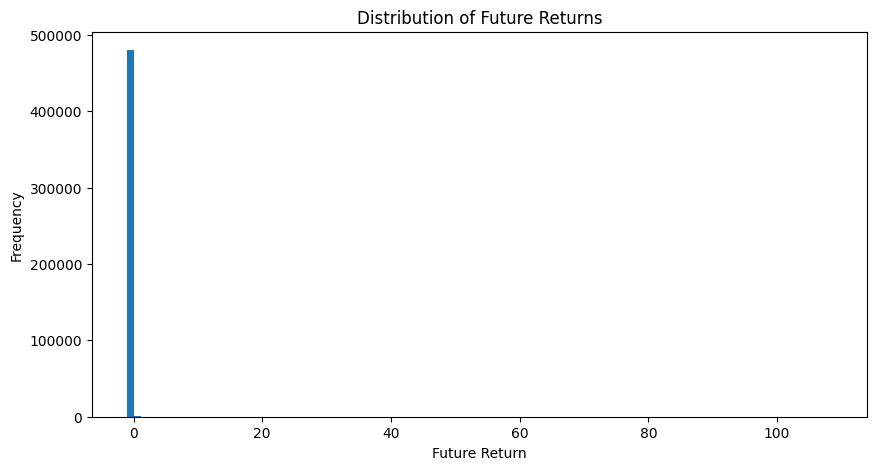

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df["Future_Return"], bins=100)

plt.title("Distribution of Future Returns")
plt.xlabel("Future Return")
plt.ylabel("Frequency")

plt.show()

In [51]:
df["Target_Signal"].value_counts()

Target_Signal
HOLD    222906
BUY     132826
SELL    125801
Name: count, dtype: int64

In [52]:
(
    df["Target_Signal"]
    .value_counts(normalize=True)
    * 100
).round(2)

Target_Signal
HOLD    46.29
BUY     27.58
SELL    26.13
Name: proportion, dtype: float64

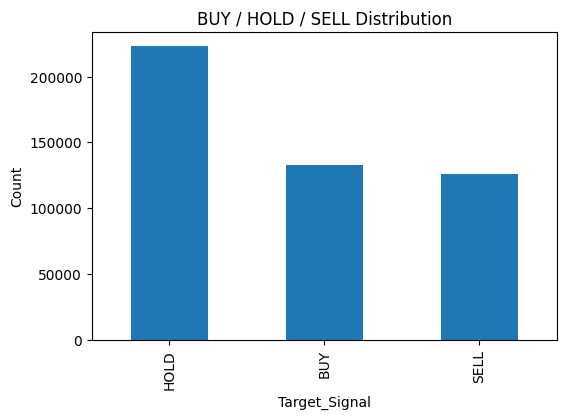

In [53]:
df["Target_Signal"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("BUY / HOLD / SELL Distribution")
plt.ylabel("Count")

plt.show()

In [54]:
df.nlargest(10, "Future_Return")[
    ["Ticker", "Date", "Close", "Target_Close", "Future_Return"]
]

,Ticker,Date,Close,Target_Close,Future_Return
48812,BAJFINANCE,2005-07-27,2.310208,252.951706,108.493063
155279,EICHERMOT,2005-07-27,23.056576,230.565826,9.000003
199119,HINDPETRO,2005-07-27,19.560432,132.032959,5.750002
172494,GRASIM,2005-07-27,149.679230,970.034119,5.480753
236523,IOC,2005-07-27,13.238174,79.429070,5.000002
85816,BPCL,2005-07-27,12.737401,76.424400,5.000000
75168,BIOCON,2005-07-27,31.487194,188.923141,4.999999
161845,GAIL,2005-07-27,14.743541,78.632202,4.333332
96464,CANBK,2005-07-27,28.870667,148.411682,4.140570
149955,DRREDDY,2005-07-27,70.506950,352.534851,4.000001


In [55]:
df.nsmallest(10, "Future_Return")[
    ["Ticker", "Date", "Close", "Target_Close", "Future_Return"]
]

,Ticker,Date,Close,Target_Close,Future_Return
48813,BAJFINANCE,2005-07-28,252.951706,2.312484,-0.990858
44186,BAJAJFINSV,2008-05-23,660.177979,48.534531,-0.926483
155280,EICHERMOT,2005-07-28,230.565826,22.939425,-0.900508
199120,HINDPETRO,2005-07-28,132.032959,18.931452,-0.856616
172495,GRASIM,2005-07-28,970.034119,149.915054,-0.845454
236524,IOC,2005-07-28,79.429070,13.098998,-0.835086
75169,BIOCON,2005-07-28,188.923141,31.888910,-0.831207
85817,BPCL,2005-07-28,76.424400,12.956523,-0.830466
161846,GAIL,2005-07-28,78.632202,14.652768,-0.813654
101790,CHOLAFIN,2005-07-28,114.370224,22.578047,-0.802588


In [56]:
df[
    (df["Date"] >= "2005-07-20") &
    (df["Date"] <= "2005-08-05") &
    (df["Ticker"] == "BAJFINANCE")
][["Date", "Close"]]

,Date,Close
48807,2005-07-20,2.298993
48808,2005-07-21,2.276311
48809,2005-07-22,2.310208
48810,2005-07-25,2.309449
48811,2005-07-26,2.349414
48812,2005-07-27,2.310208
48813,2005-07-28,252.951706
48814,2005-07-29,2.312484
48815,2005-08-01,2.341404
48816,2005-08-02,2.307846


In [57]:
df[
    (df["Future_Return"] > 1) |
    (df["Future_Return"] < -0.8)
].shape

(26, 28)

In [58]:
df[
    (df["Future_Return"] > 1) |
    (df["Future_Return"] < -0.8)
][
    ["Ticker", "Date", "Close", "Target_Close", "Future_Return"]
].sort_values(["Ticker", "Date"])

,Ticker,Date,Close,Target_Close,Future_Return
44186,BAJAJFINSV,2008-05-23,660.177979,48.534531,-0.926483
48812,BAJFINANCE,2005-07-27,2.310208,252.951706,108.493063
48813,BAJFINANCE,2005-07-28,252.951706,2.312484,-0.990858
75168,BIOCON,2005-07-27,31.487194,188.923141,4.999999
75169,BIOCON,2005-07-28,188.923141,31.888910,-0.831207
85816,BPCL,2005-07-27,12.737401,76.424400,5.000000
85817,BPCL,2005-07-28,76.424400,12.956523,-0.830466
96464,CANBK,2005-07-27,28.870667,148.411682,4.140570
101789,CHOLAFIN,2005-07-27,22.874044,114.370224,4.000000
101790,CHOLAFIN,2005-07-28,114.370224,22.578047,-0.802588


In [59]:
outliers = df[
    (df["Future_Return"] > 1) |
    (df["Future_Return"] < -0.8)
]

print("Outliers found:", len(outliers))

Outliers found: 26


In [60]:
outliers.to_csv(
    "D:/projects/AI-Stock-Analytics-System/data/processed/outliers_removed.csv",
    index=False
)

In [61]:
df = df[
    (df["Future_Return"] <= 1) &
    (df["Future_Return"] >= -0.8)
].reset_index(drop=True)

In [62]:
print(df.shape)

(481406, 28)


In [63]:
df["Future_Return"].describe()

count    481406.000000
mean          0.000859
std           0.023613
min          -0.797221
25%          -0.010630
50%           0.000065
75%           0.011509
max           1.000000
Name: Future_Return, dtype: float64

In [64]:
print(df.isnull().sum())

Date                 0
Close                0
High                 0
Low                  0
Open                 0
Volume               0
Ticker               0
Daily_Return       101
MA5                404
MA10               909
MA20              1919
MA50              4949
EMA20                0
RSI               2551
EMA12                0
EMA26                0
MACD                 0
Signal_Line          0
MACD_Histogram       0
Upper_Band        1919
Lower_Band        1919
Volatility        2020
Lag1               101
Lag2               202
Lag3               303
Target_Close         0
Future_Return        0
Target_Signal        0
dtype: int64


In [65]:
df = df.dropna().reset_index(drop=True)

In [66]:
print(df.shape)

(475258, 28)


In [67]:
print(df.isnull().sum())

Date              0
Close             0
High              0
Low               0
Open              0
Volume            0
Ticker            0
Daily_Return      0
MA5               0
MA10              0
MA20              0
MA50              0
EMA20             0
RSI               0
EMA12             0
EMA26             0
MACD              0
Signal_Line       0
MACD_Histogram    0
Upper_Band        0
Lower_Band        0
Volatility        0
Lag1              0
Lag2              0
Lag3              0
Target_Close      0
Future_Return     0
Target_Signal     0
dtype: int64


In [68]:
FEATURE_PATH = r"D:\projects\AI-Stock-Analytics-System\data\final"

os.makedirs(FEATURE_PATH, exist_ok=True)

df.to_csv(
    os.path.join(
        FEATURE_PATH,
        "feature_engineered_stock_data.csv"
    ),
    index=False
)

print("Feature Engineering Completed Successfully!")

Feature Engineering Completed Successfully!


In [69]:
df["Future_Return"].describe()

count    475258.000000
mean          0.000862
std           0.023580
min          -0.797221
25%          -0.010645
50%           0.000143
75%           0.011553
max           1.000000
Name: Future_Return, dtype: float64

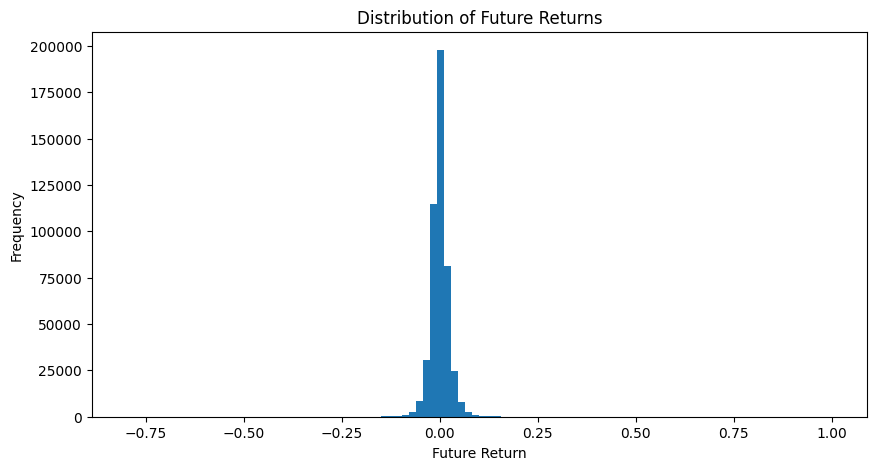

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["Future_Return"], bins=100)
plt.title("Distribution of Future Returns")
plt.xlabel("Future Return")
plt.ylabel("Frequency")
plt.show()

adding features to improve accuracy 

In [71]:
pip install ta

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
from ta.volatility import AverageTrueRange
from ta.trend import ADXIndicator
from ta.volume import OnBalanceVolumeIndicator
from ta.momentum import StochasticOscillator
from ta.trend import CCIIndicator

In [73]:
atr = AverageTrueRange(
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    window=14
)

df["ATR"] = atr.average_true_range()

df[["ATR"]].head(20)

,ATR
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
5,0.000000
6,0.000000
7,0.000000
8,0.000000
9,0.000000


In [74]:
adx = ADXIndicator(
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    window=14
)

df["ADX"] = adx.adx()

df[["ADX"]].head(30)

,ADX
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
5,0.000000
6,0.000000
7,0.000000
8,0.000000
9,0.000000


In [75]:
obv = OnBalanceVolumeIndicator(
    close=df["Close"],
    volume=df["Volume"]
)

df["OBV"] = obv.on_balance_volume()

df[["OBV"]].head()

,OBV
0,671263.0
1,-97989.0
2,-1687010.0
3,-724269.0
4,77957.0


In [76]:
stochastic = StochasticOscillator(
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    window=14,
    smooth_window=3
)

df["Stochastic"] = stochastic.stoch()

df[["Stochastic"]].head(30)

,Stochastic
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,NaN
8,NaN
9,NaN


In [77]:
cci = CCIIndicator(
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    window=20
)

df["CCI"] = cci.cci()

df[["CCI"]].head(20)

,CCI
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,NaN
8,NaN
9,NaN


In [78]:
new_features = [
    "ATR",
    "ADX",
    "OBV",
    "Stochastic",
    "CCI"
]

df[new_features].head(30)

,ATR,ADX,OBV,Stochastic,CCI
0,0.000000,0.000000,671263.0,NaN,NaN
1,0.000000,0.000000,-97989.0,NaN,NaN
2,0.000000,0.000000,-1687010.0,NaN,NaN
3,0.000000,0.000000,-724269.0,NaN,NaN
4,0.000000,0.000000,77957.0,NaN,NaN
5,0.000000,0.000000,-959835.0,NaN,NaN
6,0.000000,0.000000,-1810331.0,NaN,NaN
7,0.000000,0.000000,-993534.0,NaN,NaN
8,0.000000,0.000000,-1830925.0,NaN,NaN
9,0.000000,0.000000,-2911297.0,NaN,NaN


In [79]:
df[new_features].isnull().sum()

ATR            0
ADX            0
OBV            0
Stochastic    15
CCI           19
dtype: int64

In [80]:
df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)

print(df.shape)

(475237, 33)


In [81]:
df.to_csv(
    r"D:\projects\AI-Stock-Analytics-System\data\final\feature_engineered_stock_data.csv",
    index=False
)

print("Updated dataset saved successfully.")

Updated dataset saved successfully.


In [82]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker',
       'Daily_Return', 'MA5', 'MA10', 'MA20', 'MA50', 'EMA20', 'RSI', 'EMA12',
       'EMA26', 'MACD', 'Signal_Line', 'MACD_Histogram', 'Upper_Band',
       'Lower_Band', 'Volatility', 'Lag1', 'Lag2', 'Lag3', 'Target_Close',
       'Future_Return', 'Target_Signal', 'ATR', 'ADX', 'OBV', 'Stochastic',
       'CCI'],
      dtype='object')

In [83]:
df.shape

(475237, 33)

In [84]:
# Distance from MA20
df["Price_vs_MA20"] = (
    (df["Close"] - df["MA20"]) / df["MA20"]
)

# Difference between EMA12 and EMA26
df["EMA_Diff"] = (
    df["EMA12"] - df["EMA26"]
)

# Bollinger Band Width
df["BB_Width"] = (
    (df["Upper_Band"] - df["Lower_Band"]) / df["MA20"]
)

In [85]:
df[
    [
        "Price_vs_MA20",
        "EMA_Diff",
        "BB_Width"
    ]
].isnull().sum()

Price_vs_MA20    0
EMA_Diff         0
BB_Width         0
dtype: int64

In [86]:
df.to_csv(
    "../data/final/feature_engineered_stock_data.csv",
    index=False
)

print("Dataset Updated Successfully")


Dataset Updated Successfully


In [87]:
df.shape

(475237, 36)

In [88]:
print(df["Ticker"].nunique())
print(df["Ticker"].unique()[:10])

101
['ACC' 'ADANIPORTS' 'ADANIPOWER' 'ALKEM' 'AMBUJACEM' 'ASHOKLEY'
 'AUROPHARMA' 'AXISBANK' 'BAJAJ-AUTO' 'BAJAJFINSV']


In [90]:
import yfinance as yf
import pandas as pd

In [91]:
df["Date"] = pd.to_datetime(df["Date"])

In [92]:
nifty = yf.download(
    "^NSEI",
    start=df["Date"].min(),
    end=df["Date"].max(),
    auto_adjust=True
)

nifty.reset_index(inplace=True)

nifty.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
0,2007-09-17,4494.649902,4549.049805,4482.850098,4518.450195,0
1,2007-09-18,4546.200195,4551.799805,4481.549805,4494.100098,0
2,2007-09-19,4732.350098,4739.000000,4550.250000,4550.250000,0
3,2007-09-20,4747.549805,4760.850098,4721.149902,4734.850098,0
4,2007-09-21,4837.549805,4855.700195,4733.700195,4752.950195,0


In [93]:
vix = yf.download(
    "^INDIAVIX",
    start=df["Date"].min(),
    end=df["Date"].max(),
    auto_adjust=True
)

vix.reset_index(inplace=True)

vix.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,^INDIAVIX,^INDIAVIX,^INDIAVIX,^INDIAVIX,^INDIAVIX
0,2008-03-03,35.759998,41.540001,28.490000,28.490000,0
1,2008-03-04,38.080002,51.070000,30.590000,38.080002,0
2,2008-03-05,35.509998,38.759998,27.950001,38.080002,0
3,2008-03-07,35.200001,39.340000,27.049999,36.950001,0
4,2008-03-10,32.580002,47.950001,25.330000,25.330000,0


In [94]:
banknifty = yf.download(
    "^NSEBANK",
    start=df["Date"].min(),
    end=df["Date"].max(),
    auto_adjust=True
)

banknifty.reset_index(inplace=True)

banknifty.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,^NSEBANK,^NSEBANK,^NSEBANK,^NSEBANK,^NSEBANK
0,2007-09-17,6897.020020,6977.119187,6842.920550,6897.919911,0
1,2007-09-18,7059.567871,7078.867940,6883.520112,6921.069480,0
2,2007-09-19,7401.764160,7419.263957,7110.917439,7110.917439,0
3,2007-09-20,7390.063965,7462.813119,7343.514701,7404.864086,0
4,2007-09-21,7464.413086,7506.262696,7367.064122,7378.213894,0


In [95]:
nifty["NIFTY_Return"] = nifty["Close"].pct_change()

nifty = nifty[
    [
        "Date",
        "Close",
        "NIFTY_Return"
    ]
]

nifty.rename(
    columns={
        "Close":"NIFTY_Close"
    },
    inplace=True
)

In [96]:
banknifty["BankNIFTY_Return"] = banknifty["Close"].pct_change()

banknifty = banknifty[
    [
        "Date",
        "Close",
        "BankNIFTY_Return"
    ]
]

banknifty.rename(
    columns={
        "Close":"BankNIFTY_Close"
    },
    inplace=True
)

In [97]:
vix = vix[
    [
        "Date",
        "Close"
    ]
]

vix.rename(
    columns={
        "Close":"India_VIX"
    },
    inplace=True
)

In [100]:
print(nifty.columns)

MultiIndex([(        'Date',      ''),
            ( 'NIFTY_Close', '^NSEI'),
            ('NIFTY_Return',      '')],
           names=['Price', 'Ticker'])


In [101]:
# Remove the second level of the MultiIndex
nifty.columns = nifty.columns.get_level_values(0)

banknifty.columns = banknifty.columns.get_level_values(0)

vix.columns = vix.columns.get_level_values(0)

In [102]:
df = df.merge(
    nifty,
    on="Date",
    how="left"
)

In [103]:
print(nifty.columns)

Index(['Date', 'NIFTY_Close', 'NIFTY_Return'], dtype='object', name='Price')


In [104]:
# Merge NIFTY
df = df.merge(
    nifty,
    on="Date",
    how="left"
)

# Merge India VIX
df = df.merge(
    vix,
    on="Date",
    how="left"
)

# Merge Bank NIFTY
df = df.merge(
    banknifty,
    on="Date",
    how="left"
)

In [117]:
market_features = [
    "NIFTY_Close",
    "NIFTY_Return",
    "India_VIX",
    "BankNIFTY_Close",
    
    "BankNIFTY_Return"
]

print(df[market_features].isnull().sum())

NIFTY_Close         46442
NIFTY_Return        46517
India_VIX           55594
BankNIFTY_Close     45094
BankNIFTY_Return    45169
dtype: int64


In [106]:
print(df.columns.tolist())

['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Daily_Return', 'MA5', 'MA10', 'MA20', 'MA50', 'EMA20', 'RSI', 'EMA12', 'EMA26', 'MACD', 'Signal_Line', 'MACD_Histogram', 'Upper_Band', 'Lower_Band', 'Volatility', 'Lag1', 'Lag2', 'Lag3', 'Target_Close', 'Future_Return', 'Target_Signal', 'ATR', 'ADX', 'OBV', 'Stochastic', 'CCI', 'Price_vs_MA20', 'EMA_Diff', 'BB_Width', 'NIFTY_Close_x', 'NIFTY_Return_x', 'NIFTY_Close_y', 'NIFTY_Return_y', 'India_VIX', 'BankNIFTY_Close', 'BankNIFTY_Return']


In [107]:
print(nifty.columns.tolist())

['Date', 'NIFTY_Close', 'NIFTY_Return']


In [108]:
print(df["Date"].dtype)
print(nifty["Date"].dtype)

datetime64[ns]
datetime64[ns]


In [111]:
df[
    [
        "NIFTY_Close_x",
        "NIFTY_Close_y",
        "NIFTY_Return_x",
        "NIFTY_Return_y"
    ]
].head()

,NIFTY_Close_x,NIFTY_Close_y,NIFTY_Return_x,NIFTY_Return_y
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN


In [112]:
df["NIFTY_Close"] = df["NIFTY_Close_x"]

df["NIFTY_Return"] = df["NIFTY_Return_x"]

In [113]:
df.drop(
    columns=[
        "NIFTY_Close_x",
        "NIFTY_Close_y",
        "NIFTY_Return_x",
        "NIFTY_Return_y"
    ],
    inplace=True
)

In [115]:
print(df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker',
       'Daily_Return', 'MA5', 'MA10', 'MA20', 'MA50', 'EMA20', 'RSI', 'EMA12',
       'EMA26', 'MACD', 'Signal_Line', 'MACD_Histogram', 'Upper_Band',
       'Lower_Band', 'Volatility', 'Lag1', 'Lag2', 'Lag3', 'Target_Close',
       'Future_Return', 'Target_Signal', 'ATR', 'ADX', 'OBV', 'Stochastic',
       'CCI', 'Price_vs_MA20', 'EMA_Diff', 'BB_Width', 'India_VIX',
       'BankNIFTY_Close', 'BankNIFTY_Return', 'NIFTY_Close', 'NIFTY_Return'],
      dtype='object')


In [116]:
market_features = [
    "NIFTY_Close",
    "NIFTY_Return",
    "India_VIX",
    "BankNIFTY_Close",
    "BankNIFTY_Return"
]

print(df[market_features].isnull().sum())

NIFTY_Close         46442
NIFTY_Return        46517
India_VIX           55594
BankNIFTY_Close     45094
BankNIFTY_Return    45169
dtype: int64


In [118]:
market_features = [
    "NIFTY_Close",
    "NIFTY_Return",
    "India_VIX",
    "BankNIFTY_Close",
    "BankNIFTY_Return"
]

print(df[market_features].isnull().sum())

NIFTY_Close         46442
NIFTY_Return        46517
India_VIX           55594
BankNIFTY_Close     45094
BankNIFTY_Return    45169
dtype: int64


In [119]:
df[market_features].isnull().sum()

NIFTY_Close         46442
NIFTY_Return        46517
India_VIX           55594
BankNIFTY_Close     45094
BankNIFTY_Return    45169
dtype: int64

In [120]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [121]:
df[market_features].isnull().sum()

NIFTY_Close         0
NIFTY_Return        0
India_VIX           0
BankNIFTY_Close     0
BankNIFTY_Return    0
dtype: int64

In [122]:
df[
    [
        "Date",
        "Ticker",
        "NIFTY_Close",
        "NIFTY_Return",
        "India_VIX",
        "BankNIFTY_Close",
        "BankNIFTY_Return"
    ]
].head(15)

,Date,Ticker,NIFTY_Close,NIFTY_Return,India_VIX,BankNIFTY_Close,BankNIFTY_Return
0,2008-03-03,ACC,4953.000000,-0.051785,35.759998,8047.356445,-0.073765
1,2008-03-04,ACC,4864.250000,-0.017918,38.080002,7736.510254,-0.038627
2,2008-03-05,ACC,4921.399902,0.011749,35.509998,7588.261719,-0.019162
3,2008-03-07,ACC,4771.600098,-0.030438,35.200001,7268.065430,-0.042196
4,2008-03-10,ACC,4800.399902,0.006036,32.580002,7272.415527,0.000599
5,2008-03-11,ACC,4865.899902,0.013645,32.689999,7356.314453,0.011537
6,2008-03-12,ACC,4872.000000,0.001254,32.360001,7341.464355,-0.002019
7,2008-03-13,ACC,4623.600098,-0.050985,34.150002,6914.569336,-0.058148
8,2008-03-14,ACC,4745.799805,0.026430,31.110001,7105.917480,0.027673
9,2008-03-17,ACC,4503.100098,-0.051140,33.430000,6556.124023,-0.077371


In [123]:
print(df.shape)

(418194, 41)


In [124]:
df.to_csv(
    "../data/final/feature_engineered_stock_data.csv",
    index=False
)

print("Feature engineered dataset updated successfully!")

Feature engineered dataset updated successfully!


In [125]:
df["Relative_Strength"] = (
    df["Daily_Return"] - (df["NIFTY_Return"] * 100)
)

In [126]:
df["Bank_Relative_Strength"] = (
    df["Daily_Return"] - (df["BankNIFTY_Return"] * 100)
)

In [127]:
df["Volume_Ratio"] = (
    df["Volume"] /
    df.groupby("Ticker")["Volume"].transform(
        lambda x: x.rolling(20).mean()
    )
)

In [128]:
df["Prev_Close"] = (
    df.groupby("Ticker")["Close"].shift(1)
)

df["Gap_Percentage"] = (
    (df["Open"] - df["Prev_Close"])
    / df["Prev_Close"]
) * 100

In [129]:
df["ATR_Percentage"] = (
    df["ATR"] /
    df["Close"]
) * 100

In [130]:
df["ATR_Percentage"] = (
    df["ATR"] /
    df["Close"]
) * 100

In [132]:
print(nifty.columns)

Index(['Date', 'NIFTY_Close', 'NIFTY_Return'], dtype='object', name='Price')


In [133]:
nifty["NIFTY_MA50"] = (
    nifty["NIFTY_Close"]
    .rolling(window=50)
    .mean()
)

In [134]:
print(nifty[["NIFTY_Close","NIFTY_MA50"]].head(60))

Price  NIFTY_Close   NIFTY_MA50
0      4494.649902          NaN
1      4546.200195          NaN
2      4732.350098          NaN
3      4747.549805          NaN
4      4837.549805          NaN
5      4932.200195          NaN
6      4938.850098          NaN
7      4940.500000          NaN
8      5000.549805          NaN
9      5021.350098          NaN
10     5068.950195          NaN
11     5210.799805          NaN
12     5208.649902          NaN
13     5185.850098          NaN
14     5085.100098          NaN
15     5327.250000          NaN
16     5441.450195          NaN
17     5524.850098          NaN
18     5428.250000          NaN
19     5670.399902          NaN
20     5668.049805          NaN
21     5559.299805          NaN
22     5351.000000          NaN
23     5215.299805          NaN
24     5184.000000          NaN
25     5473.700195          NaN
26     5496.149902          NaN
27     5568.950195          NaN
28     5702.299805          NaN
29     5905.899902          NaN
30     5

In [135]:
nifty["Bull_Market"] = (
    nifty["NIFTY_Close"] >
    nifty["NIFTY_MA50"]
).astype(int)

In [136]:
df = df.merge(
    nifty[["Date","Bull_Market"]],
    on="Date",
    how="left"
)

In [137]:
df["Bull_Market"] = df["Bull_Market"].ffill()

In [138]:
print(df["Bull_Market"].value_counts())

Bull_Market
1    263418
0    154776
Name: count, dtype: int64


In [139]:
print(df["Bull_Market"].isnull().sum())

0


In [140]:
new_features = [
    # Technical indicators
    "ATR",
    "ADX",
    "OBV",
    "Stochastic",
    "CCI",

    # Engineered features
    "Price_vs_MA20",
    "EMA_Diff",
    "BB_Width",

    # Market features
    "NIFTY_Close",
    "NIFTY_Return",
    "India_VIX",
    "BankNIFTY_Close",
    "BankNIFTY_Return",

    # Advanced features
    "Relative_Strength",
    "Bank_Relative_Strength",
    "Volume_Ratio",
    "Gap_Percentage",
    "ATR_Percentage",
    "Bull_Market"
]

df[new_features].isnull().sum().sort_values(ascending=False)

Volume_Ratio              1919
Gap_Percentage             101
ATR                          0
OBV                          0
ADX                          0
Stochastic                   0
CCI                          0
BB_Width                     0
NIFTY_Close                  0
Price_vs_MA20                0
EMA_Diff                     0
India_VIX                    0
NIFTY_Return                 0
BankNIFTY_Close              0
BankNIFTY_Return             0
Bank_Relative_Strength       0
Relative_Strength            0
ATR_Percentage               0
Bull_Market                  0
dtype: int64

In [141]:
df[new_features] = df[new_features].ffill()

In [142]:
df[new_features].isnull().sum()

ATR                        0
ADX                        0
OBV                        0
Stochastic                 0
CCI                        0
Price_vs_MA20              0
EMA_Diff                   0
BB_Width                   0
NIFTY_Close                0
NIFTY_Return               0
India_VIX                  0
BankNIFTY_Close            0
BankNIFTY_Return           0
Relative_Strength          0
Bank_Relative_Strength     0
Volume_Ratio              19
Gap_Percentage             1
ATR_Percentage             0
Bull_Market                0
dtype: int64

In [143]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [144]:
print(df.shape)

print(df[new_features].isnull().sum())

(418075, 48)
ATR                       0
ADX                       0
OBV                       0
Stochastic                0
CCI                       0
Price_vs_MA20             0
EMA_Diff                  0
BB_Width                  0
NIFTY_Close               0
NIFTY_Return              0
India_VIX                 0
BankNIFTY_Close           0
BankNIFTY_Return          0
Relative_Strength         0
Bank_Relative_Strength    0
Volume_Ratio              0
Gap_Percentage            0
ATR_Percentage            0
Bull_Market               0
dtype: int64


In [145]:
df.to_csv(
    "../data/final/feature_engineered_stock_data.csv",
    index=False
)

print("Final feature engineered dataset saved successfully!")

Final feature engineered dataset saved successfully!


In [146]:
print(df["Target_Signal"].value_counts(normalize=True) * 100)

Target_Signal
HOLD    46.838725
BUY     27.304670
SELL    25.856605
Name: proportion, dtype: float64


In [147]:
# Check return distribution
df["Future_Return"].describe()

count    418075.000000
mean          0.000806
std           0.022768
min          -0.648979
25%          -0.010468
50%           0.000153
75%           0.011321
max           0.462012
Name: Future_Return, dtype: float64

In [151]:
buy_threshold = df["Future_Return"].quantile(0.65)
sell_threshold = df["Future_Return"].quantile(0.35)

print("BUY Threshold :", buy_threshold)
print("SELL Threshold:", sell_threshold)

BUY Threshold : 0.006119414539701829
SELL Threshold: -0.0056384378847292825


In [152]:
def create_signal_balanced(x):
    if x >= buy_threshold:
        return "BUY"
    elif x <= sell_threshold:
        return "SELL"
    else:
        return "HOLD"

df["Target_Signal_Balanced"] = df["Future_Return"].apply(create_signal_balanced)

In [153]:
print(df["Target_Signal_Balanced"].value_counts())

print(
    df["Target_Signal_Balanced"]
      .value_counts(normalize=True) * 100
)

Target_Signal_Balanced
SELL    146326
BUY     146326
HOLD    125423
Name: count, dtype: int64
Target_Signal_Balanced
SELL    34.99994
BUY     34.99994
HOLD    30.00012
Name: proportion, dtype: float64


In [154]:
df.to_csv(
    "../data/final/feature_engineered_stock_data.csv",
    index=False
)

In [155]:
print(df.columns[df.columns.str.contains("Target")])

Index(['Target_Close', 'Target_Signal', 'Target_Signal_Balanced'], dtype='object')


In [156]:
print(df[["Future_Return", "Target_Signal"]].head(20))

    Future_Return Target_Signal
0       -0.014187          SELL
1        0.004777          HOLD
2        0.002106          HOLD
3       -0.008708          SELL
4       -0.006300          HOLD
5        0.004814          HOLD
6        0.001105          HOLD
7       -0.001718          HOLD
8       -0.009895          SELL
9       -0.006394          HOLD
10       0.001000          HOLD
11       0.026712           BUY
12       0.027658           BUY
13      -0.054773          SELL
14      -0.020776          SELL
15      -0.019747          SELL
16       0.010952           BUY
17      -0.021538          SELL
18      -0.006525          HOLD
19       0.004379          HOLD


In [157]:
print(df["Future_Return"].describe())

print(df["Target_Signal"].value_counts(normalize=True))

count    418075.000000
mean          0.000806
std           0.022768
min          -0.648979
25%          -0.010468
50%           0.000153
75%           0.011321
max           0.462012
Name: Future_Return, dtype: float64
Target_Signal
HOLD    0.399998
SELL    0.300001
BUY     0.300001
Name: proportion, dtype: float64


In [158]:
print(df["Future_Return"].min())
print(df["Future_Return"].max())

-0.6489788051152764
0.462011562205588
